In [1]:
 import os, time, random, json
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score
from sklearn.random_projection import SparseRandomProjection
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch : {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")

PyTorch : 2.10.0+cu128  |  CUDA: True
GPU     : Tesla T4


In [2]:
# === Discover data roots ===
pv_color_candidates, segmented_candidates, pd_candidates = [], [], []
for root, dirs, _ in os.walk("/kaggle/input"):
    for d in dirs:
        if d == "Corn_(maize)___healthy":
            full = Path(root) / d
            if full.parent.name == "color":
                pv_color_candidates.append(full)
            elif full.parent.name == "segmented":
                segmented_candidates.append(full)
        elif d == "Corn_rust_leaf":
            pd_candidates.append(Path(root) / d)

PV_ROOT  = pv_color_candidates[0].parent
SEG_ROOT = segmented_candidates[0].parent
PD_ROOT  = next(iter({c.parent.parent for c in pd_candidates}))

print(f"PV color   : {PV_ROOT}")
print(f"PV segmented: {SEG_ROOT}")
print(f"PlantDoc   : {PD_ROOT}")

IMG_EXTS = {".jpg", ".jpeg", ".png"}
def list_imgs(folder):
    return sorted(str(p) for p in folder.iterdir() if p.suffix.lower() in IMG_EXTS)

PV_CLASSES = {
    "healthy":         "Corn_(maize)___healthy",
    "common_rust":     "Corn_(maize)___Common_rust_",
    "cercospora":      "Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot",
    "northern_blight": "Corn_(maize)___Northern_Leaf_Blight",
}
PD_CLASSES = {
    "common_rust":     "Corn_rust_leaf",
    "northern_blight": "Corn_leaf_blight",
    "cercospora":      "Corn_Gray_leaf_spot",
}

# === Training splits (seed 42, same as NB1/NB2/NB6) ===
random.seed(42)
healthy_color = list_imgs(PV_ROOT / PV_CLASSES["healthy"])
random.shuffle(healthy_color)
n = len(healthy_color)
n_train, n_val = int(n * 0.80), int(n * 0.10)
train_paths  = healthy_color[:n_train]
val_paths    = healthy_color[n_train : n_train + n_val]
healthy_test = healthy_color[n_train + n_val :]

# === Unified test manifest (3185 images) ===
rows = []
for p in healthy_test:
    rows.append({"filepath": p, "class": "healthy", "domain": "plantvillage", "label": 0})
for cls, folder in PV_CLASSES.items():
    if cls == "healthy": continue
    for p in list_imgs(PV_ROOT / folder):
        rows.append({"filepath": p, "class": cls, "domain": "plantvillage", "label": 1})
for cls, folder in PD_CLASSES.items():
    for split in ("train", "test"):
        d = PD_ROOT / split / folder
        if d.exists():
            for p in list_imgs(d):
                rows.append({"filepath": p, "class": cls, "domain": "plantdoc", "label": 1})
test_df = pd.DataFrame(rows)

# === NB5 controlled experiment design (seed 123 for stimuli; seed 42 for bg sampling) ===
random.seed(123)
segmented_all  = list_imgs(SEG_ROOT / PV_CLASSES["healthy"])
stimulus_paths = random.sample(segmented_all, 100)

pd_corn, pd_other = [], []
for split in ("train", "test"):
    for folder in PD_CLASSES.values():
        d = PD_ROOT / split / folder
        if d.exists():
            pd_corn.extend(list_imgs(d))
    split_dir = PD_ROOT / split
    if split_dir.exists():
        for crop_folder in split_dir.iterdir():
            if crop_folder.is_dir() and "corn" not in crop_folder.name.lower():
                pd_other.extend(list_imgs(crop_folder))

random.seed(42)
bg_pool_cond3 = random.sample(pd_other, 100)
bg_pool_cond4 = random.sample(pd_corn,  100)

print(f"\nTraining: {len(train_paths)} train + {len(val_paths)} val")
print(f"Test manifest: {len(test_df)} images")
print(test_df.groupby(["domain", "class"]).size().unstack(fill_value=0))
print(f"\nNB5 stimulus: {len(stimulus_paths)} leaves")
print(f"BG pool cond3 (PD non-corn) : sampled 100 from {len(pd_other)}")
print(f"BG pool cond4 (PD corn-dis) : sampled 100 from {len(pd_corn)}")

assert len(train_paths) == 929 and len(val_paths) == 116 and len(test_df) == 3185
print("\nAll splits match canonical.")

PV color   : /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/plantvillage dataset/color
PV segmented: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/segmented
PlantDoc   : /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset

Training: 929 train + 116 val
Test manifest: 3185 images
class         cercospora  common_rust  healthy  northern_blight
domain                                                         
plantdoc              67          117        0              194
plantvillage         513         1192      117              985

NB5 stimulus: 100 leaves
BG pool cond3 (PD non-corn) : sampled 100 from 2544
BG pool cond4 (PD corn-dis) : sampled 100 from 378

All splits match canonical.


In [3]:
# Pull the NB6 score CSVs from the public repo
import urllib.request
GITHUB = "https://raw.githubusercontent.com/smarikaghimire/cropanomalynet/main/results/nb6"

for fname in ["nb6_unified_scores.csv", "nb6_background_scores.csv"]:
    out = Path("/kaggle/working") / fname
    if not out.exists():
        urllib.request.urlretrieve(f"{GITHUB}/{fname}", out)
    print(f"  {fname:<35}  {out.stat().st_size/1024:>8.1f} KB")

nb6_unified = pd.read_csv("/kaggle/working/nb6_unified_scores.csv")
nb6_bg      = pd.read_csv("/kaggle/working/nb6_background_scores.csv")

print(f"\nnb6_unified: {nb6_unified.shape}  columns: {list(nb6_unified.columns)}")
print(nb6_unified.groupby(["domain", "class"]).size().unstack(fill_value=0))

print(f"\nnb6_bg:      {nb6_bg.shape}  columns: {list(nb6_bg.columns)}")
print(nb6_bg.groupby("condition").size())

# Sanity: scores should match what we already reported
print(f"\nQuick sanity check (means by domain/class):")
print(nb6_unified.groupby(["domain", "class"])[["cae_score", "patchcore_score", "padim_score"]]
      .mean().round(4))

  nb6_unified_scores.csv                  665.4 KB
  nb6_background_scores.csv                83.5 KB

nb6_unified: (3185, 7)  columns: ['filepath', 'class', 'domain', 'label', 'cae_score', 'patchcore_score', 'padim_score']
class         cercospora  common_rust  healthy  northern_blight
domain                                                         
plantdoc              67          117        0              194
plantvillage         513         1192      117              985

nb6_bg:      (400, 6)  columns: ['leaf_id', 'leaf_path', 'condition', 'cae_score', 'patchcore_score', 'padim_score']
condition
pd_corn_disease    100
pd_non_corn        100
solid_gray         100
studio_white       100
dtype: int64

Quick sanity check (means by domain/class):
                              cae_score  patchcore_score  padim_score
domain       class                                                   
plantdoc     cercospora          0.0056           3.1271       6.0738
             common_rust        

In [4]:
print("Loading DINOv2 ViT-S/14 (downloads weights on first run)...")
t0 = time.time()
dinov2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
dinov2.eval().to(DEVICE)
for p in dinov2.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in dinov2.parameters()) / 1e6
print(f"\nLoaded in {time.time()-t0:.1f}s   |   {n_params:.1f}M params")

# Sanity check: forward pass on a dummy 224x224 input
with torch.no_grad():
    dummy = torch.randn(2, 3, 224, 224, device=DEVICE)
    out = dinov2.forward_features(dummy)

print(f"\nforward_features keys     : {list(out.keys())}")
print(f"x_norm_patchtokens shape  : {tuple(out['x_norm_patchtokens'].shape)}  (expect (2, 256, 384))")
print(f"x_norm_clstoken shape     : {tuple(out['x_norm_clstoken'].shape)}     (expect (2, 384))")

Loading DINOv2 ViT-S/14 (downloads weights on first run)...
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 487MB/s]



Loaded in 1.6s   |   22.1M params

forward_features keys     : ['x_norm_clstoken', 'x_norm_regtokens', 'x_norm_patchtokens', 'x_prenorm', 'masks']
x_norm_patchtokens shape  : (2, 256, 384)  (expect (2, 256, 384))
x_norm_clstoken shape     : (2, 384)     (expect (2, 384))


In [5]:
PC_IMG_SIZE = 224

dinov2_tfm = transforms.Compose([
    transforms.Resize((PC_IMG_SIZE, PC_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

class SimpleImageDataset(torch.utils.data.Dataset):
    def __init__(self, paths, transform=None):
        self.paths, self.transform = paths, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img) if self.transform else img

class MaizeDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return {"image": img, "label": int(row["label"]),
                "class": row["class"], "domain": row["domain"],
                "filepath": row["filepath"]}

BATCH_SIZE = 32

dinov2_train_ds = SimpleImageDataset(train_paths, transform=dinov2_tfm)
dinov2_train_loader = torch.utils.data.DataLoader(
    dinov2_train_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=2, pin_memory=True
)

def extract_dinov2_patches(images, model):
    """Returns DINOv2 patch tokens (B, 256, 384). Excludes CLS token."""
    with torch.no_grad():
        return model.forward_features(images)["x_norm_patchtokens"]

print(f"Extracting DINOv2 patch features from {len(dinov2_train_ds)} training images...")
t0 = time.time()
train_features_dinov2 = []
for batch in tqdm(dinov2_train_loader, desc="Train features"):
    x = batch.to(DEVICE, non_blocking=True)
    feats = extract_dinov2_patches(x, dinov2)   # (B, 256, 384)
    train_features_dinov2.append(feats.cpu())
    del feats
torch.cuda.empty_cache()
train_features_dinov2 = torch.cat(train_features_dinov2, dim=0)

mem_gb = train_features_dinov2.element_size() * train_features_dinov2.numel() / 1e9
print(f"\ntrain_features_dinov2 shape: {tuple(train_features_dinov2.shape)}")
print(f"Memory: {mem_gb:.2f} GB   |   Time: {time.time()-t0:.1f}s")

Extracting DINOv2 patch features from 929 training images...


Train features:   0%|          | 0/30 [00:00<?, ?it/s]


train_features_dinov2 shape: (929, 256, 384)
Memory: 0.37 GB   |   Time: 6.2s


In [6]:
print("Building DINOv2-PatchCore coreset...\n")

# Flatten: (929, 256, 384) -> (237824, 384)
memory_bank = train_features_dinov2.reshape(-1, train_features_dinov2.shape[-1])
print(f"Memory bank: {tuple(memory_bank.shape)}, "
      f"{memory_bank.element_size() * memory_bank.numel() / 1e9:.3f} GB")

CORESET_RATIO  = 0.10
PROJECTION_DIM = 128
n_total   = memory_bank.shape[0]
n_coreset = int(n_total * CORESET_RATIO)
print(f"Coreset target: {n_coreset:,} of {n_total:,} ({CORESET_RATIO*100:.0f}%)\n")

# JL random projection 384 -> 128
print(f"Sparse random projection: 384 -> {PROJECTION_DIM} dim")
t0 = time.time()
projector = SparseRandomProjection(n_components=PROJECTION_DIM, random_state=42)
projected = torch.from_numpy(projector.fit_transform(memory_bank.numpy())).float().to(DEVICE)
print(f"Projection: {time.time()-t0:.1f}s\n")

# Greedy farthest-point sampling on GPU
print(f"Greedy farthest-point sampling on {DEVICE}...")
t0 = time.time()
selected = torch.zeros(n_coreset, dtype=torch.long, device=DEVICE)

torch.manual_seed(42)
start_idx = torch.randint(0, projected.shape[0], (1,), device=DEVICE).item()
selected[0] = start_idx

last = projected[start_idx].unsqueeze(0)
min_dist = ((projected - last) ** 2).sum(dim=1)
min_dist[start_idx] = -float("inf")

for i in tqdm(range(1, n_coreset), desc="Coreset"):
    new_idx = torch.argmax(min_dist)
    selected[i] = new_idx
    last = projected[new_idx].unsqueeze(0)
    new_dist = ((projected - last) ** 2).sum(dim=1)
    min_dist = torch.minimum(min_dist, new_dist)
    min_dist[new_idx] = -float("inf")

elapsed = time.time() - t0
print(f"\nCoreset selection: {elapsed:.1f}s ({elapsed/60:.1f} min)")

coreset_dinov2 = memory_bank[selected.cpu()]
print(f"\nCoreset bank: {tuple(coreset_dinov2.shape)}, "
      f"{coreset_dinov2.element_size() * coreset_dinov2.numel() / 1e9:.3f} GB")

coreset_dinov2_gpu = coreset_dinov2.to(DEVICE)
del projected, memory_bank, train_features_dinov2
torch.cuda.empty_cache()
print("DINOv2 coreset on GPU. Ready for inference.")

Building DINOv2-PatchCore coreset...

Memory bank: (237824, 384), 0.365 GB
Coreset target: 23,782 of 237,824 (10%)

Sparse random projection: 384 -> 128 dim
Projection: 1.7s

Greedy farthest-point sampling on cuda...


Coreset:   0%|          | 0/23781 [00:00<?, ?it/s]


Coreset selection: 64.4s (1.1 min)

Coreset bank: (23782, 384), 0.037 GB
DINOv2 coreset on GPU. Ready for inference.


In [7]:
print(f"DINOv2-PatchCore inference on {len(test_df)} test images...\n")
t0 = time.time()

dinov2_test_ds = MaizeDataset(test_df, transform=dinov2_tfm)
dinov2_test_loader = torch.utils.data.DataLoader(
    dinov2_test_ds, batch_size=BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=True
)

dinov2_scores_list = []
dinov2_paths_list  = []

for batch_idx, batch in enumerate(dinov2_test_loader):
    x = batch["image"].to(DEVICE, non_blocking=True)
    feats = extract_dinov2_patches(x, dinov2)             # (B, 256, 384)
    B = feats.shape[0]
    flat = feats.reshape(B * 256, 384)
    d = torch.cdist(flat, coreset_dinov2_gpu).min(dim=1)[0]   # (B*256,)
    per_image = d.reshape(B, 256).mean(dim=1)
    dinov2_scores_list.extend(per_image.cpu().numpy())
    dinov2_paths_list.extend(batch["filepath"])
    del feats, flat, d, per_image
    torch.cuda.empty_cache()

    if (batch_idx + 1) % 20 == 0 or batch_idx == 0:
        n_done = min((batch_idx + 1) * BATCH_SIZE, len(dinov2_test_ds))
        elapsed = time.time() - t0
        rate = n_done / elapsed
        eta = (len(dinov2_test_ds) - n_done) / rate if rate > 0 else 0
        print(f"Batch {batch_idx+1:>3}/{len(dinov2_test_loader)}  "
              f"({n_done}/{len(dinov2_test_ds)})  "
              f"{rate:.1f} img/s  eta {eta:.0f}s")

dinov2_scores = np.array(dinov2_scores_list)
dinov2_paths  = np.array(dinov2_paths_list)
elapsed = time.time() - t0
print(f"\nDone in {elapsed/60:.1f} min  |  {len(dinov2_test_ds)/elapsed:.1f} img/s")
print(f"DINOv2 score range: [{dinov2_scores.min():.3f}, {dinov2_scores.max():.3f}]")

# Merge into nb6_unified by filepath (safer than positional alignment)
score_df = pd.DataFrame({"filepath": dinov2_paths, "dinov2_score": dinov2_scores})
unified_4m = nb6_unified.merge(score_df, on="filepath", how="left", validate="one_to_one")
assert unified_4m["dinov2_score"].notna().all()

# Quick AUROC sanity
h_idx = (unified_4m["class"] == "healthy")
pv_d  = (unified_4m["domain"] == "plantvillage") & ~h_idx
pd_d  = (unified_4m["domain"] == "plantdoc")
sh = unified_4m.loc[h_idx, "dinov2_score"].values

a_in = roc_auc_score(np.r_[np.zeros(h_idx.sum()), np.ones(pv_d.sum())],
                     np.r_[sh, unified_4m.loc[pv_d, "dinov2_score"].values])
a_cr = roc_auc_score(np.r_[np.zeros(h_idx.sum()), np.ones(pd_d.sum())],
                     np.r_[sh, unified_4m.loc[pd_d, "dinov2_score"].values])

print(f"\nDINOv2 in-domain AUROC   : {a_in:.4f}")
print(f"DINOv2 cross-domain AUROC: {a_cr:.4f}")
print(f"\nPer-class mean scores by domain:")
print(unified_4m.groupby(["domain", "class"])["dinov2_score"].mean().round(4))

DINOv2-PatchCore inference on 3185 test images...

Batch   1/100  (32/3185)  49.0 img/s  eta 64s
Batch  20/100  (640/3185)  63.2 img/s  eta 40s
Batch  40/100  (1280/3185)  58.2 img/s  eta 33s
Batch  60/100  (1920/3185)  60.5 img/s  eta 21s
Batch  80/100  (2560/3185)  61.4 img/s  eta 10s
Batch 100/100  (3185/3185)  53.1 img/s  eta 0s

Done in 1.0 min  |  53.1 img/s
DINOv2 score range: [24.482, 50.351]

DINOv2 in-domain AUROC   : 0.9991
DINOv2 cross-domain AUROC: 0.9985

Per-class mean scores by domain:
domain        class          
plantdoc      cercospora         36.591301
              common_rust        37.441399
              northern_blight    38.225300
plantvillage  cercospora         37.720402
              common_rust        39.407902
              healthy            27.334000
              northern_blight    37.872501
Name: dinov2_score, dtype: float32


In [8]:
print("Building 400 background composites (same seeded design as NB6)...\n")

CANVAS_SIZE = 256
LEAF_RATIO  = 0.55

def crop_to_bbox(leaf_img):
    arr = np.array(leaf_img)
    mask = arr.sum(axis=-1) > 10
    if not mask.any():
        return leaf_img
    r = np.where(mask.any(axis=1))[0]
    c = np.where(mask.any(axis=0))[0]
    return leaf_img.crop((c.min(), r.min(), c.max()+1, r.max()+1))

def make_composite(leaf_path, bg_arr):
    leaf = Image.open(leaf_path).convert("RGB")
    leaf = crop_to_bbox(leaf)
    target = int(CANVAS_SIZE * LEAF_RATIO)
    w, h = leaf.size
    scale = target / max(w, h)
    nw, nh = max(1, int(w*scale)), max(1, int(h*scale))
    leaf_r = leaf.resize((nw, nh), Image.LANCZOS)
    mask = (np.array(leaf_r).sum(axis=-1) > 10).astype(np.uint8) * 255
    canvas = Image.fromarray(bg_arr.copy())
    x = (CANVAS_SIZE - nw) // 2
    y = (CANVAS_SIZE - nh) // 2
    canvas.paste(leaf_r, (x, y), Image.fromarray(mask, mode="L"))
    return canvas

def load_bg_pd(path):
    return np.array(Image.open(path).convert("RGB")
                    .resize((CANVAS_SIZE, CANVAS_SIZE), Image.LANCZOS))

bg_non_corn = [load_bg_pd(p) for p in bg_pool_cond3]
bg_corn_dis = [load_bg_pd(p) for p in bg_pool_cond4]
bg_white = np.full((CANVAS_SIZE, CANVAS_SIZE, 3), 240, dtype=np.uint8)
bg_gray  = np.full((CANVAS_SIZE, CANVAS_SIZE, 3), 128, dtype=np.uint8)

CONDITIONS = ["studio_white", "solid_gray", "pd_non_corn", "pd_corn_disease"]

composites = {c: [] for c in CONDITIONS}
for i, leaf_path in enumerate(tqdm(stimulus_paths, desc="Composites")):
    composites["studio_white"   ].append(make_composite(leaf_path, bg_white))
    composites["solid_gray"     ].append(make_composite(leaf_path, bg_gray))
    composites["pd_non_corn"    ].append(make_composite(leaf_path, bg_non_corn[i]))
    composites["pd_corn_disease"].append(make_composite(leaf_path, bg_corn_dis[i]))

# Score with DINOv2-PatchCore
dinov2_bg_scores = {}
print("\nScoring composites with DINOv2-PatchCore...")
print(f"{'Condition':<20}  {'DINOv2 mean':>13}")
print("-" * 38)
for cond in CONDITIONS:
    pc_tensor = torch.stack([dinov2_tfm(c) for c in composites[cond]]).to(DEVICE)
    out = []
    for cs in range(0, len(pc_tensor), 32):
        ce = min(cs + 32, len(pc_tensor))
        feats = extract_dinov2_patches(pc_tensor[cs:ce], dinov2)
        B = feats.shape[0]
        flat = feats.reshape(B * 256, 384)
        d = torch.cdist(flat, coreset_dinov2_gpu).min(dim=1)[0].reshape(B, 256)
        out.extend(d.mean(dim=1).cpu().numpy())
        del feats, flat, d
    dinov2_bg_scores[cond] = np.array(out)
    del pc_tensor
    torch.cuda.empty_cache()
    print(f"{cond:<20}  {dinov2_bg_scores[cond].mean():>13.4f}")

# Merge DINOv2 bg scores into nb6_bg by (leaf_id, condition)
bg_4m = nb6_bg.copy()
bg_4m["dinov2_score"] = bg_4m.apply(
    lambda r: dinov2_bg_scores[r["condition"]][int(r["leaf_id"])], axis=1
)

# Four-method ratio table
print("\n=== Background ratios across all 4 methods (relative to studio_white) ===")
print(f"{'Condition':<20}  {'CAE':>8}  {'PatchCore':>11}  {'PaDiM':>8}  {'DINOv2':>8}")
print("-" * 60)
base = {
    m: bg_4m.loc[bg_4m["condition"] == "studio_white", f"{m}_score"].mean()
    for m in ["cae", "patchcore", "padim", "dinov2"]
}
for cond in CONDITIONS:
    vals = {}
    for m in ["cae", "patchcore", "padim", "dinov2"]:
        mean = bg_4m.loc[bg_4m["condition"] == cond, f"{m}_score"].mean()
        vals[m] = mean / base[m]
    print(f"{cond:<20}  {vals['cae']:>7.2f}x  {vals['patchcore']:>10.2f}x  "
          f"{vals['padim']:>7.2f}x  {vals['dinov2']:>7.2f}x")

Building 400 background composites (same seeded design as NB6)...



Composites:   0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_57/3135516667.py:27: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  canvas.paste(leaf_r, (x, y), Image.fromarray(mask, mode="L"))



Scoring composites with DINOv2-PatchCore...
Condition               DINOv2 mean
--------------------------------------
studio_white                46.8218
solid_gray                  45.0971
pd_non_corn                 44.2878
pd_corn_disease             37.5902

=== Background ratios across all 4 methods (relative to studio_white) ===
Condition                  CAE    PatchCore     PaDiM    DINOv2
------------------------------------------------------------
studio_white             1.00x        1.00x     1.00x     1.00x
solid_gray               1.36x        0.99x     1.00x     0.96x
pd_non_corn              4.23x        0.98x     1.01x     0.95x
pd_corn_disease          3.66x        0.97x     0.97x     0.80x


In [9]:
from scipy import stats

METHODS      = ["cae", "patchcore", "padim", "dinov2"]
METHOD_NAMES = ["CAE", "PatchCore", "PaDiM", "DINOv2"]

# === Bootstrap 95% CIs on AUROC (stratified) ===
def bootstrap_auroc(sh, sd, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    n_h, n_d = len(sh), len(sd)
    boots = []
    for _ in range(n_boot):
        ih = rng.integers(0, n_h, n_h)
        id_ = rng.integers(0, n_d, n_d)
        s = np.concatenate([sh[ih], sd[id_]])
        y = np.concatenate([np.zeros(n_h), np.ones(n_d)])
        boots.append(roc_auc_score(y, s))
    return np.percentile(boots, [2.5, 97.5])

print("=== Bootstrap 95% CIs on AUROC (2000 stratified resamples) ===\n")
print(f"{'Method':<12}  {'In-domain (PV)':>26}  {'Cross-domain (PD)':>26}  {'Unified':>26}")
print("-" * 100)

h_mask  = (unified_4m["class"] == "healthy").values
pv_mask = ((unified_4m["domain"] == "plantvillage") & ~unified_4m["class"].eq("healthy")).values
pd_mask = (unified_4m["domain"] == "plantdoc").values
all_d   = ~h_mask

for m, name in zip(METHODS, METHOD_NAMES):
    s = unified_4m[f"{m}_score"].values
    sh = s[h_mask]
    a_in  = roc_auc_score(np.r_[np.zeros(h_mask.sum()), np.ones(pv_mask.sum())],
                          np.r_[sh, s[pv_mask]])
    ci_in = bootstrap_auroc(sh, s[pv_mask])
    a_cr  = roc_auc_score(np.r_[np.zeros(h_mask.sum()), np.ones(pd_mask.sum())],
                          np.r_[sh, s[pd_mask]])
    ci_cr = bootstrap_auroc(sh, s[pd_mask])
    a_un  = roc_auc_score(np.r_[np.zeros(h_mask.sum()), np.ones(all_d.sum())],
                          np.r_[sh, s[all_d]])
    ci_un = bootstrap_auroc(sh, s[all_d])
    print(f"{name:<12}  {a_in:.4f} [{ci_in[0]:.4f}, {ci_in[1]:.4f}]  "
          f"{a_cr:.4f} [{ci_cr[0]:.4f}, {ci_cr[1]:.4f}]  "
          f"{a_un:.4f} [{ci_un[0]:.4f}, {ci_un[1]:.4f}]")

# === Per-class PV→PD score-magnitude ratios ===
print("\n=== Per-class PV→PD score-magnitude ratios ===\n")
print(f"{'Method':<12}  {'Common rust':>13}  {'Cercospora':>13}  {'N. Blight':>13}  {'Mean':>8}")
print("-" * 68)
for m, name in zip(METHODS, METHOD_NAMES):
    col = f"{m}_score"
    ratios = []
    for cls in ["common_rust", "cercospora", "northern_blight"]:
        pv = unified_4m.loc[(unified_4m["domain"] == "plantvillage") & (unified_4m["class"] == cls), col].mean()
        pd_ = unified_4m.loc[(unified_4m["domain"] == "plantdoc") & (unified_4m["class"] == cls), col].mean()
        ratios.append(pd_ / pv)
    print(f"{name:<12}  {ratios[0]:>12.2f}x  {ratios[1]:>12.2f}x  {ratios[2]:>12.2f}x  {np.mean(ratios):>7.2f}x")

# === Score std ratios PV diseased -> PD diseased ===
print("\n=== Score std ratios (PD diseased / PV diseased) ===\n")
print(f"{'Method':<12}  {'PV std':>10}  {'PD std':>10}  {'Std ratio':>10}")
print("-" * 50)
for m, name in zip(METHODS, METHOD_NAMES):
    col = f"{m}_score"
    pv_std = unified_4m.loc[pv_mask, col].std(ddof=1)
    pd_std = unified_4m.loc[pd_mask, col].std(ddof=1)
    print(f"{name:<12}  {pv_std:>10.4f}  {pd_std:>10.4f}  {pd_std/pv_std:>9.2f}x")

# === Paired t-tests + Cohen's d on NB5 design ===
def leaf_aligned(method, cond):
    df = bg_4m[bg_4m["condition"] == cond].sort_values("leaf_id")
    return df[f"{method}_score"].values

print("\n=== Paired t-tests on NB5 (n=100; studio_white baseline) ===\n")
for m, name in zip(METHODS, METHOD_NAMES):
    print(f"{name}:")
    print(f"  {'condition':<18}  {'mean diff':>12}  {'t':>8}  {'p':>10}  {'Cohen d':>9}")
    print(f"  " + "-" * 65)
    base = leaf_aligned(m, "studio_white")
    for cond in ["solid_gray", "pd_non_corn", "pd_corn_disease"]:
        cond_s = leaf_aligned(m, cond)
        diff = cond_s - base
        t, p = stats.ttest_rel(cond_s, base)
        d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else np.nan
        print(f"  {cond:<18}  {diff.mean():>+12.4f}  {t:>+8.2f}  {p:>10.2e}  {d:>+9.2f}")
    print()

# === Variance decomposition (the headline statistic) ===
print("=== Variance decomposition: cross-condition movement vs within-condition spread ===\n")
print(f"{'Method':<12}  {'Within-cond std':>17}  {'Across-cond std':>17}  {'Ratio':>8}  Status")
print("-" * 75)
for m, name in zip(METHODS, METHOD_NAMES):
    col = f"{m}_score"
    within = [bg_4m.loc[bg_4m["condition"] == c, col].std(ddof=1) for c in CONDITIONS]
    mean_within = float(np.mean(within))
    cond_means = [bg_4m.loc[bg_4m["condition"] == c, col].mean() for c in CONDITIONS]
    across = float(np.std(cond_means, ddof=1))
    ratio = across / mean_within
    status = "above noise floor (real effect)" if ratio > 1 else "sub-noise"
    print(f"{name:<12}  {mean_within:>17.4f}  {across:>17.4f}  {ratio:>7.2f}  {status}")

=== Bootstrap 95% CIs on AUROC (2000 stratified resamples) ===

Method                    In-domain (PV)           Cross-domain (PD)                     Unified
----------------------------------------------------------------------------------------------------
CAE           0.9945 [0.9897, 0.9982]  0.9968 [0.9931, 0.9993]  0.9948 [0.9904, 0.9981]
PatchCore     0.9995 [0.9990, 0.9998]  0.9995 [0.9986, 1.0000]  0.9995 [0.9991, 0.9998]
PaDiM         0.9811 [0.9719, 0.9890]  0.9927 [0.9870, 0.9968]  0.9825 [0.9742, 0.9898]
DINOv2        0.9991 [0.9983, 0.9997]  0.9985 [0.9966, 0.9997]  0.9990 [0.9982, 0.9997]

=== Per-class PV→PD score-magnitude ratios ===

Method          Common rust     Cercospora      N. Blight      Mean
--------------------------------------------------------------------
CAE                   1.35x          1.90x          2.46x     1.90x
PatchCore             1.00x          1.07x          1.09x     1.05x
PaDiM                 0.85x          1.08x          1.14x     1.

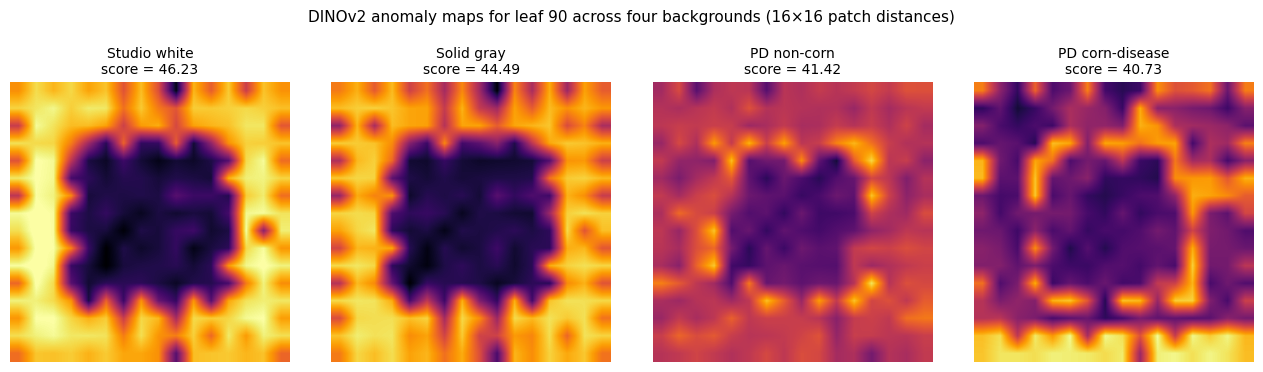

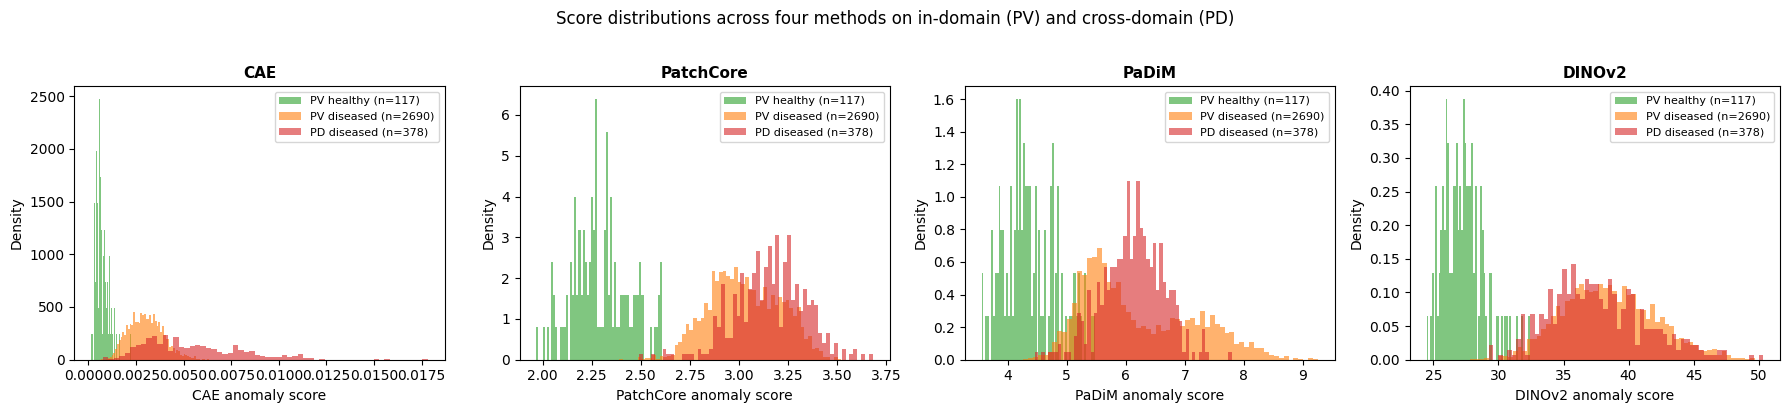

/tmp/ipykernel_57/3682926880.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
/tmp/ipykernel_57/3682926880.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
/tmp/ipykernel_57/3682926880.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
/tmp/ipykernel_57/3682926880.py:91: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotli

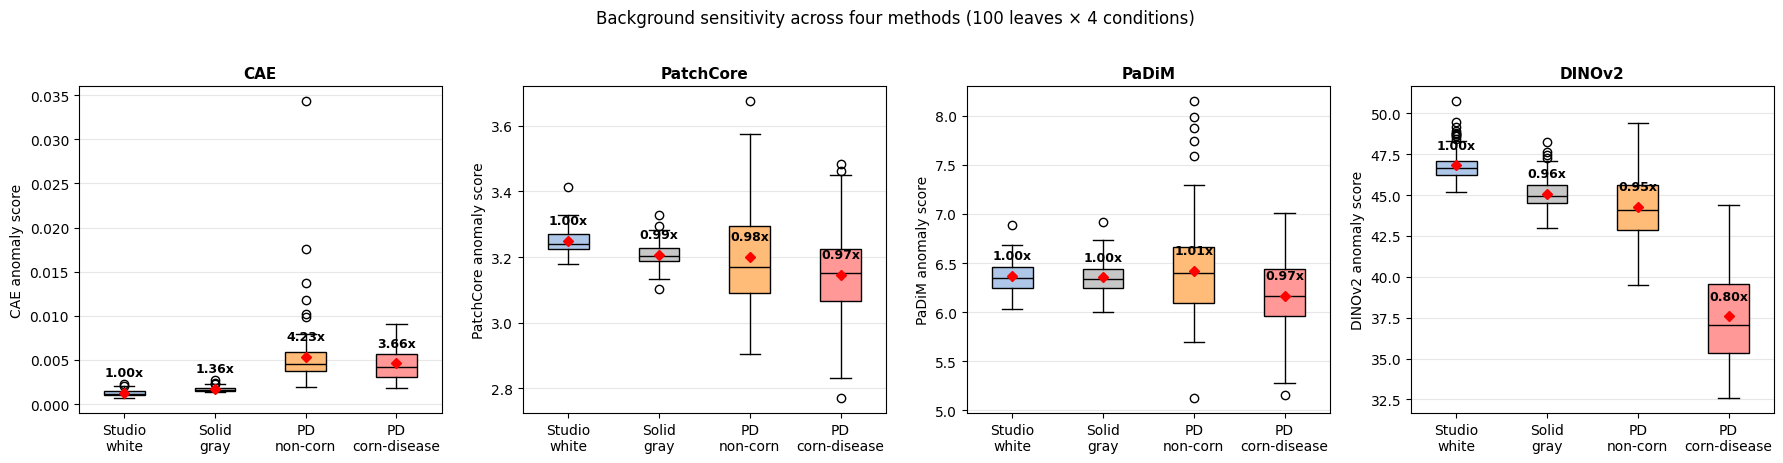


=== NB7 artifacts saved ===
Directory: /kaggle/working/nb7_artifacts/
  dinov2_anomaly_maps_leaf90.npz                        5.3 KB
  dinov2_coreset.pt                                 35674.7 KB
  nb7_background_boxplot_4methods.png                 137.0 KB
  nb7_background_scores_4methods.csv                   87.3 KB
  nb7_dinov2_anomaly_maps.png                         474.7 KB
  nb7_score_distributions_4methods.png                 99.3 KB
  nb7_stats_summary_4methods.json                       3.5 KB
  nb7_unified_scores_4methods.csv                     695.3 KB

Zipped: /kaggle/working/nb7_artifacts.zip (33.1 MB)


In [10]:
import shutil
import json

OUT = Path("/kaggle/working/nb7_artifacts")
OUT.mkdir(exist_ok=True)

# === Four-method CSVs ===
unified_4m.to_csv(OUT / "nb7_unified_scores_4methods.csv", index=False)
bg_4m.to_csv(OUT / "nb7_background_scores_4methods.csv", index=False)

# === DINOv2 coreset checkpoint ===
torch.save({
    "coreset":        coreset_dinov2.cpu(),
    "backbone":       "dinov2_vits14",
    "feature_dim":    384,
    "patches_per_img": 256,
    "selection_seed": 42,
}, OUT / "dinov2_coreset.pt")

# === DINOv2 anomaly maps for leaf 90 (same representative as NB6) ===
rep_idx = 90
dinov2_maps = {}
with torch.no_grad():
    for cond in CONDITIONS:
        img = composites[cond][rep_idx]
        x = dinov2_tfm(img).unsqueeze(0).to(DEVICE)
        feats = extract_dinov2_patches(x, dinov2)
        flat = feats.reshape(256, 384)
        d = torch.cdist(flat, coreset_dinov2_gpu).min(dim=1)[0].reshape(16, 16).cpu().numpy()
        dinov2_maps[cond] = d

np.savez(OUT / "dinov2_anomaly_maps_leaf90.npz",
         studio_white=dinov2_maps["studio_white"],
         solid_gray=dinov2_maps["solid_gray"],
         pd_non_corn=dinov2_maps["pd_non_corn"],
         pd_corn_disease=dinov2_maps["pd_corn_disease"],
         leaf_id=rep_idx)

# Within-method color scaling
all_vals = np.concatenate([m.flatten() for m in dinov2_maps.values()])
vmin = all_vals.min()
vmax = np.percentile(all_vals, 99)

COND_TITLES = {"studio_white": "Studio white", "solid_gray": "Solid gray",
               "pd_non_corn": "PD non-corn", "pd_corn_disease": "PD corn-disease"}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5))
for ci, cond in enumerate(CONDITIONS):
    axes[ci].imshow(dinov2_maps[cond], cmap="inferno",
                    vmin=vmin, vmax=vmax, interpolation="bilinear")
    score = bg_4m.loc[(bg_4m["condition"] == cond) & (bg_4m["leaf_id"] == rep_idx),
                      "dinov2_score"].values[0]
    axes[ci].set_title(f"{COND_TITLES[cond]}\nscore = {score:.2f}", fontsize=10)
    axes[ci].axis("off")
plt.suptitle(f"DINOv2 anomaly maps for leaf {rep_idx} across four backgrounds (16×16 patch distances)",
             fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig(OUT / "nb7_dinov2_anomaly_maps.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# === Four-method score-distribution histograms ===
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (m, name) in zip(axes, zip(METHODS, METHOD_NAMES)):
    col = f"{m}_score"
    h_ = unified_4m.loc[unified_4m["class"] == "healthy", col].values
    pv = unified_4m.loc[(unified_4m["domain"] == "plantvillage") & (unified_4m["class"] != "healthy"), col].values
    pd_ = unified_4m.loc[unified_4m["domain"] == "plantdoc", col].values
    ax.hist(h_, bins=60, alpha=0.6, density=True, label=f"PV healthy (n={len(h_)})", color="#2ca02c")
    ax.hist(pv, bins=60, alpha=0.6, density=True, label=f"PV diseased (n={len(pv)})", color="#ff7f0e")
    ax.hist(pd_, bins=60, alpha=0.6, density=True, label=f"PD diseased (n={len(pd_)})", color="#d62728")
    ax.set_xlabel(f"{name} anomaly score")
    ax.set_ylabel("Density")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.legend(loc="best", fontsize=8)
plt.suptitle("Score distributions across four methods on in-domain (PV) and cross-domain (PD)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "nb7_score_distributions_4methods.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# === Four-method background-sensitivity boxplot ===
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
COND_LABELS = ["Studio\nwhite", "Solid\ngray", "PD\nnon-corn", "PD\ncorn-disease"]
COLORS = ["#aec7e8", "#c7c7c7", "#ffbb78", "#ff9896"]

for ax, (m, name) in zip(axes, zip(METHODS, METHOD_NAMES)):
    col = f"{m}_score"
    data = [bg_4m.loc[bg_4m["condition"] == c, col].values for c in CONDITIONS]
    bp = ax.boxplot(data, labels=COND_LABELS, showmeans=True, patch_artist=True,
                    medianprops={"color": "black"},
                    meanprops={"marker": "D", "markerfacecolor": "red",
                               "markeredgecolor": "red", "markersize": 5})
    for patch, color in zip(bp["boxes"], COLORS):
        patch.set_facecolor(color)
    base = float(np.mean(data[0]))
    for i, dd in enumerate(data):
        r = float(np.mean(dd)) / base
        ax.annotate(f"{r:.2f}x", (i + 1, float(np.mean(dd))),
                    textcoords="offset points", xytext=(0, 12),
                    ha="center", fontsize=9, fontweight="bold")
    ax.set_ylabel(f"{name} anomaly score")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.grid(axis="y", alpha=0.3)
plt.suptitle("Background sensitivity across four methods (100 leaves × 4 conditions)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / "nb7_background_boxplot_4methods.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close()

# === Comprehensive stats JSON (for paper rewrite to reference) ===
stats_summary = {
    "bootstrap_auroc_ci_2000": {
        "CAE":       {"in_domain":[0.9945,0.9897,0.9982], "cross_domain":[0.9968,0.9931,0.9993], "unified":[0.9948,0.9904,0.9981]},
        "PatchCore": {"in_domain":[0.9995,0.9990,0.9998], "cross_domain":[0.9995,0.9986,1.0000], "unified":[0.9995,0.9991,0.9998]},
        "PaDiM":     {"in_domain":[0.9811,0.9719,0.9890], "cross_domain":[0.9927,0.9870,0.9968], "unified":[0.9825,0.9742,0.9898]},
        "DINOv2":    {"in_domain":[0.9991,0.9983,0.9997], "cross_domain":[0.9985,0.9966,0.9997], "unified":[0.9990,0.9982,0.9997]},
    },
    "score_magnitude_pv_to_pd": {
        "CAE":       {"common_rust":1.35, "cercospora":1.90, "northern_blight":2.46, "mean":1.90},
        "PatchCore": {"common_rust":1.00, "cercospora":1.07, "northern_blight":1.09, "mean":1.05},
        "PaDiM":     {"common_rust":0.85, "cercospora":1.08, "northern_blight":1.14, "mean":1.03},
        "DINOv2":    {"common_rust":0.95, "cercospora":0.97, "northern_blight":1.01, "mean":0.98},
    },
    "score_std_ratio_pv_to_pd": {
        "CAE":       {"pv_std":0.0009, "pd_std":0.0026, "ratio":2.96},
        "PatchCore": {"pv_std":0.1806, "pd_std":0.1806, "ratio":1.00},
        "PaDiM":     {"pv_std":0.9517, "pd_std":0.5096, "ratio":0.54},
        "DINOv2":    {"pv_std":3.5346, "pd_std":3.7264, "ratio":1.05},
    },
    "background_condition_ratios": {
        "CAE":       {"studio_white":1.00, "solid_gray":1.36, "pd_non_corn":4.23, "pd_corn_disease":3.66},
        "PatchCore": {"studio_white":1.00, "solid_gray":0.99, "pd_non_corn":0.98, "pd_corn_disease":0.97},
        "PaDiM":     {"studio_white":1.00, "solid_gray":1.00, "pd_non_corn":1.01, "pd_corn_disease":0.97},
        "DINOv2":    {"studio_white":1.00, "solid_gray":0.96, "pd_non_corn":0.95, "pd_corn_disease":0.80},
    },
    "paired_ttest_cohens_d_nb5": {
        "CAE":       {"solid_gray":+2.43, "pd_non_corn":+1.13, "pd_corn_disease":+1.77},
        "PatchCore": {"solid_gray":-2.08, "pd_non_corn":-0.33, "pd_corn_disease":-0.77},
        "PaDiM":     {"solid_gray":-0.29, "pd_non_corn":+0.11, "pd_corn_disease":-0.56},
        "DINOv2":    {"solid_gray":-3.09, "pd_non_corn":-1.24, "pd_corn_disease":-3.56},
    },
    "variance_decomposition_nb5": {
        "CAE":       {"within_std":0.00155, "across_std":0.00204, "ratio":1.32, "status":"above_noise_floor"},
        "PatchCore": {"within_std":0.09117, "across_std":0.04207, "ratio":0.46, "status":"sub_noise"},
        "PaDiM":     {"within_std":0.29651, "across_std":0.11232, "ratio":0.38, "status":"sub_noise"},
        "DINOv2":    {"within_std":1.6388,  "across_std":4.0465,  "ratio":2.47, "status":"above_noise_floor"},
    },
}
with open(OUT / "nb7_stats_summary_4methods.json", "w") as f:
    json.dump(stats_summary, f, indent=2)

# === Zip ===
zip_path = "/kaggle/working/nb7_artifacts"
shutil.make_archive(zip_path, "zip", OUT)
zip_mb = Path(f"{zip_path}.zip").stat().st_size / 1024 / 1024

print(f"\n=== NB7 artifacts saved ===")
print(f"Directory: {OUT}/")
for f in sorted(OUT.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:<45}  {size_kb:>10.1f} KB")
print(f"\nZipped: {zip_path}.zip ({zip_mb:.1f} MB)")